# 1. Introduction

Accurately predicting housing prices is a central problem in real estate, with important implications for buyers, sellers, and investors. Housing markets are influenced by a wide range of factors, including location, property characteristics, and broader economic conditions, making price estimation a complex and data-driven task.

In this essay, we explore how machine learning techniques can be used to predict housing prices based on structured data. Using a dataset containing features such as square footage, number of bedrooms, and neighborhood characteristics, we investigate how different variables contribute to price variation, we'll build an XGBoost model to estimate property values.

This analysis is for the Kaggle competition, "House Prices - Advanced Regression Techniques," and we will be using the data provided on the [competition website](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data).

We begin by performing exploratory data analysis to understand the structure and relationships within the dataset. We then implement and fine-tune a model to predict housing prices as accurately as possible. Finally, we analyze the strengths and limitations of our model and discuss potential improvements.

Through this process, the essay demonstrates how computational methods can be applied to a real-world problem, highlighting both the power and challenges of predictive modeling in housing markets.

In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\yongg\AppData\Local\Python\pythoncore-3.14-64\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\yongg\OneDrive\Desktop\studying\Coding Projects\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\yongg\OneDrive\Desktop\studying\Coding Projects\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Users\yongg\AppData\Local\Python\pythoncore-3.14-64\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1398, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<f

# 2. Data Preprocessing

## 2.1. Initial Glance

We should first take a look at what our data looks like, and what each column means.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('train.csv')
data.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,...,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,...,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,...,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,...,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,

Since each house is labeled with a unique ID number, we will just use that as the index for our dataframe to simplify identification of rows.

In [3]:
data.set_index(data['Id'],inplace=True)
del data['Id']
data.head(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900


## 2.2. Missing Data

Although we will be implementing a model that does not require data imputation, it is insightful for us to get an idea of what we data are missing.

In [4]:
for column in data.columns:
    num_missing = data[column].isnull().sum()
    if num_missing:
        print(f"{column} Missing Values: {num_missing}")

LotFrontage Missing Values: 259
Alley Missing Values: 1369
MasVnrType Missing Values: 872
MasVnrArea Missing Values: 8
BsmtQual Missing Values: 37
BsmtCond Missing Values: 37
BsmtExposure Missing Values: 38
BsmtFinType1 Missing Values: 37
BsmtFinType2 Missing Values: 38
Electrical Missing Values: 1
FireplaceQu Missing Values: 690
GarageType Missing Values: 81
GarageYrBlt Missing Values: 81
GarageFinish Missing Values: 81
GarageQual Missing Values: 81
GarageCond Missing Values: 81
PoolQC Missing Values: 1453
Fence Missing Values: 1179
MiscFeature Missing Values: 1406


We notice a large number of missing values in columns `Alley`, `PoolQC`, `Fence`, and `MiscFeatures`. 

- `Alley`: Type of alley access
- `PoolQC`: Pool quality
- `Fence`: Fence quality
- `MiscFeatures`: $Value of miscellaneous feature

It would make sense that some of these columns don't have much data. For example, pool quality and fence quality will be missing for houses without a pool. Similarly, not all houses have alleys and miscellaneous features.

## 2.3. Encoding Data

There are many categorical variables in our dataset, which we will need to encode to a numeric value for our model to intepret. However, we will not worry about it yet because we will set XGBoost's `enable_categorical` parameter to `True` to handle both ordinal and cardinal categorical variables. This feature in XGBoost automatically decides how to encode categorical variables using either label or one-hot encoding depending on the number of categories. It uses an algorithm called "optimal partitioning" which finds the best grouping of categories at each split, which is often better than manual encoding. 

# 3. Feature Engineering

## 3.1. Features Function
We will implement some additional features to help our model learn. Additionally, we'll get rid of outliers.

One of the most important features in this dataset is the neighborhood. We will engineer extra features around this to give tiers to the neighborhood. This function can be found in `feature_engineering.py`

In [5]:
from feature_engineering import engineer_features

## 3.2. Missing Data Function

We will need to deal with the fact that some data in our validation data won't appear in our training data. Therefore, we need to remove those missing values or else our model will be skewed. This function can also be found in `feature_engineering.py`

In [6]:
from feature_engineering import fill_missing

# 4. Creating our XGBoost Model

## 4.1. Splitting Data

We will split our data into training and testing with a 80/20 split. We will also split the data randomly for validation purposes. We will also take $\log(1+y)$ so that we are minimizing our model for RMSLE. We will also need to convert our categorical variables to Pandas' `category` type.

In [7]:
from sklearn.model_selection import train_test_split

# ── columns confirmed as zero importance or redundant ────────────────────────
drop_cols = [
    # zero importance
    "HasGarage", "HasFireplace", "Has2ndFloor", "HasBasement", "HasPool",
    "IsNewHouse", "Is1pt5Story", "3SsnPorch", "LowQualFinSF", "Condition2",
    "Heating", "Street", "Utilities", "PoolQC", "PoolArea",
    "MiscFeature", "BsmtHalfBath", "Alley",
    
    # redundant — correlated >0.99 with engineered versions
    "YearBuilt",     # replaced by HouseAge
    "GarageYrBlt",   # replaced by GarageAge
    "YearRemodAdd",  # replaced by RemodAge
]

# ── remove outliers ───────────────────────────────────────────────────────────
data = data[~((data["GrLivArea"] > 4000) & (data["SalePrice"] < 200000))]
abnormal_mask = (data["SaleCondition"] == "Abnorml") & \
                ((data["SalePrice"] < 50000) | (data["SalePrice"] > 500000))
data = data[~abnormal_mask]

X = data.drop(["SalePrice"], axis=1)
y = np.log1p(data["SalePrice"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── feature engineering then null fill ───────────────────────────────────────
X_train = engineer_features(X_train)
X_test  = engineer_features(X_test)

X_train = fill_missing(X_train)
X_test  = fill_missing(X_test)

# move drop_cols to section 4.1 so ALL models use the same features
X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# ── cast to category ──────────────────────────────────────────────────────────
cat_cols = X_train.select_dtypes(include=["object", "str"]).columns
X_train[cat_cols] = X_train[cat_cols].astype("category")
for col in cat_cols:
    train_cats = X_train[col].cat.categories
    X_test[col] = X_test[col].astype("category").cat.set_categories(train_cats)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (1163, 142)
X_test shape:  (291, 142)


## 4.2. Initial Model

Now we will create our initial XGBoost model with basic parameters. We will implement techniques such as early stopping, subsampling, regularization, etc. to reduce the chance of overfitting.

In [8]:
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.metrics import root_mean_squared_error

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    random_state=42,
    early_stopping_rounds=30,
    min_child_weight=10,
    gamma=0.05,
    reg_alpha=0.05,
    reg_lambda=1.0,
    enable_categorical = True
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

# make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# evaluate
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"Training RMSE: {train_rmse:.5f}")
print(f"Testing RMSE: {test_rmse:.5f}")

[0]	validation_0-rmse:0.38959
[100]	validation_0-rmse:0.11990
[199]	validation_0-rmse:0.11935
Training RMSE: 0.06904
Testing RMSE: 0.11929


## 4.3. Hyperparameter Tuning

With our initial model completed, we will need to move into hyperparameter tuning. For this step, we will use Optuna to help us find the best hyperparameters. We will also build in cross-validation into our training process to ensure that if our model is overfit, there's evidence to suggest that it is helpful memorization.

In [10]:
import optuna
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING) # stop printing every result

def objective(trial):
    params = {
        "objective":          "reg:squarederror",
        "learning_rate":      trial.suggest_float("learning_rate",    0.01,  0.05, log=True),
        "max_depth":          trial.suggest_int(  "max_depth",        2,     8),
        "subsample":          trial.suggest_float("subsample",        0.6,   1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.6,   1.0),
        "min_child_weight":   trial.suggest_int(  "min_child_weight", 1,     20),
        "gamma":              trial.suggest_float("gamma",            0,     1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha",        0.01,  2.5,  log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda",       0.01,  2.5,  log=True),
        "n_estimators":       5000,
        "early_stopping_rounds": 50,
        "eval_metric":        "rmse",
        "random_state":       42,
        "enable_categorical": True,
    }

    price_buckets = pd.qcut(y_train, q=10, labels=False)
    skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof           = np.zeros(len(X_train))

    for train_idx, val_idx in skf.split(X_train, price_buckets):
        X_tr  = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # ── same neighbourhood encoding as cross_validate_xgb_stratified ─────
        nbr_mean = y_tr.groupby(X_tr["Neighborhood"].astype(str)).mean()
        nbr_std  = y_tr.groupby(X_tr["Neighborhood"].astype(str)).std()
        nbr_cov  = nbr_std / nbr_mean

        X_tr["Nbr_MeanPrice"]       = X_tr["Neighborhood"].astype(str).map(nbr_mean)
        X_val["Nbr_MeanPrice"]      = X_val["Neighborhood"].astype(str).map(nbr_mean).fillna(y_tr.mean())
        X_tr["Nbr_StdPrice"]        = X_tr["Neighborhood"].astype(str).map(nbr_std)
        X_val["Nbr_StdPrice"]       = X_val["Neighborhood"].astype(str).map(nbr_std).fillna(y_tr.std())
        X_tr["Nbr_CoV"]             = X_tr["Neighborhood"].astype(str).map(nbr_cov)
        X_val["Nbr_CoV"]            = X_val["Neighborhood"].astype(str).map(nbr_cov).fillna(nbr_cov.mean())
        X_tr["QualStdInteraction"]  = X_tr["OverallQual"] * X_tr["Nbr_StdPrice"]
        X_val["QualStdInteraction"] = X_val["OverallQual"] * X_val["Nbr_StdPrice"]
        X_tr["SFStdInteraction"]    = X_tr["TotalSF"]     * X_tr["Nbr_StdPrice"]
        X_val["SFStdInteraction"]   = X_val["TotalSF"]    * X_val["Nbr_StdPrice"]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        oof[val_idx] = model.predict(X_val)

    return root_mean_squared_error(y_train, oof)


xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest OOF RMSE:  {xgb_study.best_value:.5f}")
print(f"Best params:    {xgb_study.best_params}")

[I 2026-03-22 10:10:29,821] A new study created in memory with name: no-name-e7212dc7-3cad-4397-8bdd-3d059c4c11fa
Best trial: 0. Best value: 0.126175:   2%|▏         | 1/50 [00:01<01:18,  1.60s/it]

[I 2026-03-22 10:10:31,424] Trial 0 finished with value: 0.12617496204505899 and parameters: {'learning_rate': 0.039144376815390916, 'max_depth': 6, 'subsample': 0.8561443593484428, 'colsample_bytree': 0.841879137580242, 'min_child_weight': 2, 'gamma': 0.14638029730757196, 'reg_alpha': 0.925308578609704, 'reg_lambda': 0.29340683235873133}. Best is trial 0 with value: 0.12617496204505899.


Best trial: 0. Best value: 0.126175:   4%|▍         | 2/50 [00:03<01:32,  1.92s/it]

[I 2026-03-22 10:10:33,572] Trial 1 finished with value: 0.13415067477894346 and parameters: {'learning_rate': 0.02693853702669833, 'max_depth': 4, 'subsample': 0.6872455602618028, 'colsample_bytree': 0.682527318356324, 'min_child_weight': 12, 'gamma': 0.5805255005495136, 'reg_alpha': 0.18499508650165322, 'reg_lambda': 0.3399912708371949}. Best is trial 0 with value: 0.12617496204505899.


Best trial: 0. Best value: 0.126175:   6%|▌         | 3/50 [00:06<01:53,  2.41s/it]

...

[I 2026-03-22 10:12:43,164] Trial 47 finished with value: 0.11652514623762468 and parameters: {'learning_rate': 0.03391614246868199, 'max_depth': 6, 'subsample': 0.8725501868071026, 'colsample_bytree': 0.7544183363408703, 'min_child_weight': 13, 'gamma': 0.00018789186513238338, 'reg_alpha': 0.462829527056254, 'reg_lambda': 0.04593550809063138}. Best is trial 21 with value: 0.11420491416497522.


Best trial: 21. Best value: 0.114205:  98%|█████████▊| 49/50 [02:15<00:02,  2.68s/it]

[I 2026-03-22 10:12:45,507] Trial 48 finished with value: 0.1181290003829159 and parameters: {'learning_rate': 0.0383905448274685, 'max_depth': 8, 'subsample': 0.7905218000553602, 'colsample_bytree': 0.6599783922531666, 'min_child_weight': 19, 'gamma': 0.042281210195082304, 'reg_alpha': 0.2955166886108411, 'reg_lambda': 0.39612747735161624}. Best is trial 21 with value: 0.11420491416497522.


Best trial: 21. Best value: 0.114205: 100%|██████████| 50/50 [02:17<00:00,  2.75s/it]

[I 2026-03-22 10:12:47,089] Trial 49 finished with value: 0.14507545097996108 and parameters: {'learning_rate': 0.028212799019176754, 'max_depth': 5, 'subsample': 0.7473756346293697, 'colsample_bytree': 0.7763829915232787, 'min_child_weight': 18, 'gamma': 0.8932002862431716, 'reg_alpha': 1.0738363654546577, 'reg_lambda': 0.06436459235019504}. Best is trial 21 with value: 0.11420491416497522.

Best OOF RMSE:  0.11420
Best params:    {'learning_rate': 0.03096017319248215, 'max_depth': 5, 'subsample': 0.7962350876257654, 'colsample_bytree': 0.7430360795653194, 'min_child_weight': 17, 'gamma': 0.0001257928710359335, 'reg_alpha': 0.4674179121596884, 'reg_lambda': 0.06460733709626323}


# 5. Model Validation

## 5.1. Stratified K-Folds Cross Validation

In [12]:
from model_validation import cross_validate_xgb_stratified

xgb_params = xgb_study.best_params

xgb_params = {
    **xgb_params,
    "objective":   "reg:squarederror",
    "eval_metric": "rmse",
    "random_state": 42,
}

# ── Run XGBoost ───────────────────────────────────────────────────────────────
xgb_models, xgb_oof, xgb_fold_scores = cross_validate_xgb_stratified(
    X_train, y_train,
    xgb_params,
    n_splits=5,
    n_estimators=7000,
    early_stopping_rounds=30
)


--- Fold 1 / 5 ---
[0]	validation_0-rmse:0.37801
[100]	validation_0-rmse:0.13286
[200]	validation_0-rmse:0.12305
[300]	validation_0-rmse:0.12082
[400]	validation_0-rmse:0.11980
[500]	validation_0-rmse:0.11942
[531]	validation_0-rmse:0.11960
Fold 1 RMSE: 0.11941 | Best iteration: 501

--- Fold 2 / 5 ---
[0]	validation_0-rmse:0.38892
[100]	validation_0-rmse:0.13011
[200]	validation_0-rmse:0.11540
[300]	validation_0-rmse:0.11217
[400]	validation_0-rmse:0.11171
[448]	validation_0-rmse:0.11159
Fold 2 RMSE: 0.11151 | Best iteration: 418

--- Fold 3 / 5 ---
[0]	validation_0-rmse:0.38438
[100]	validation_0-rmse:0.13255
[200]	validation_0-rmse:0.12432
[300]	validation_0-rmse:0.12215
[400]	validation_0-rmse:0.12129
[493]	validation_0-rmse:0.12105
Fold 3 RMSE: 0.12096 | Best iteration: 463

--- Fold 4 / 5 ---
[0]	validation_0-rmse:0.35716
[100]	validation_0-rmse:0.10864
[200]	validation_0-rmse:0.10394
[300]	validation_0-rmse:0.10186
[400]	validation_0-rmse:0.10123
[500]	validation_0-rmse:0.10050

## 5.2. Error Analysis

We'll take a look at the houses that produce the most error and their properties to analyze what needs improvement in our model.

### Find Largest Percent Errors

In [13]:
# find which houses have the worst OOF predictions
oof_errors = pd.DataFrame({
    "actual":    np.expm1(y_train),
    "predicted": np.expm1(xgb_oof),
    "error":     np.abs(np.expm1(y_train) - np.expm1(xgb_oof)),
    "pct_error": np.abs(np.expm1(y_train) - np.expm1(xgb_oof)) / np.expm1(y_train)
}, index=X_train.index)

worst = oof_errors.nlargest(20, "pct_error")
print(worst)

        actual      predicted          error  pct_error
Id                                                     
633    82500.0  174234.466321   91734.466321   1.111933
1325  147000.0  280554.023378  133554.023378   0.908531
534    39300.0   71657.734711   32357.734711   0.823352
411    60000.0  108117.631652   48117.631652   0.801961
1454   84500.0  140771.495633   56271.495633   0.665935
589   143000.0  225756.807574   82756.807574   0.578719
875    66500.0  104653.148272   38153.148272   0.573732
67    180000.0  276898.322829   96898.322829   0.538324
1433   64500.0   98890.786302   34390.786302   0.533190
692   755000.0  398946.261643  356053.738357   0.471594
432    79900.0  117285.698705   37385.698705   0.467906
1063   90000.0  131779.474607   41779.474607   0.464216
971   135000.0   78797.003902   56202.996098   0.416318
1280   68400.0   95193.314653   26793.314653   0.391715
667   129000.0  179332.590250   50332.590250   0.390175
689   392000.0  246174.565082  145825.434918   0

### Find Commonalities Between Inaccurate Predictions

In [14]:
# check which features the worst houses have in common
print(X_train.loc[worst.index, ["Neighborhood", "BldgType", 
                                 "HouseStyle", "OverallQual", 
                                 "TotalSF"]].to_string())

     Neighborhood BldgType HouseStyle  OverallQual   TotalSF
Id                                                          
633        NWAmes     1Fam     1Story            7  7.936660
1325      Somerst     1Fam     1Story            8  8.186186
534       BrkSide     1Fam     1Story            1  5.814131
411       Edwards     1Fam     1Story            5  7.845024
1454      Mitchel     1Fam     1Story            5  7.732369
589       ClearCr     1Fam     1Story            5  7.976252
875       OldTown     1Fam     1.5Fin            5  7.499977
67          NAmes     1Fam     1Story            7  8.332068
1433      OldTown     1Fam     1Story            4  7.393263
692       NoRidge     1Fam     2Story           10  8.818926
432       OldTown     1Fam     1.5Fin            6  7.649693
1063      OldTown   2fmCon     2Story            5  8.006368
971         NAmes     1Fam     1.5Fin            4  7.556428
1280       IDOTRR     1Fam     1.5Fin            4  7.510431
667         NAmes     1F

In [15]:
investigate_ids = [633, 1325, 411, 589, 1454, 1280, 1132, 480]

check_cols = [
    "SaleCondition", "SaleType", "Functional",
    "OverallCond", "ExterCond", "BsmtCond", "BsmtExposure",
    "MSSubClass", "LotArea", "LotConfig", "LotShape",
    "Neighborhood", "BldgType", "HouseStyle",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd",
    "GarageType", "GarageCars", "WoodDeckSF",
    "MoSold", "YrSold", "SalePrice"
]

print(data.loc[data.index.isin(investigate_ids), check_cols].to_string())

# look at every single feature for id 633
print(data.loc[633].to_string())

     SaleCondition SaleType Functional  OverallCond ExterCond BsmtCond BsmtExposure  MSSubClass  LotArea LotConfig LotShape Neighborhood BldgType HouseStyle  BedroomAbvGr  KitchenAbvGr  TotRmsAbvGrd GarageType  GarageCars  WoodDeckSF  MoSold  YrSold  SalePrice
Id                                                                                                                                                                                                                                                                  
411        Abnorml      COD        Mod            3        Fa       Fa           No          20     9571    Inside      Reg      Edwards     1Fam     1Story             3             1             5     Attchd           1           0       6    2009      60000
480         Alloca       WD        Typ            7        TA       TA           No          30     5925    Inside      Reg      OldTown     1Fam     1Story             2             1             7     Detchd        

These houses constantly reappear despite new features and hyperparameter tuning, so we will choose to make a new model to ensemble with.

# 6. Visualizations for Model

## 6.1. Most Important Features

To reduce the "black-box" feeling of our model, we can see what our model deemed the most important features for regression.

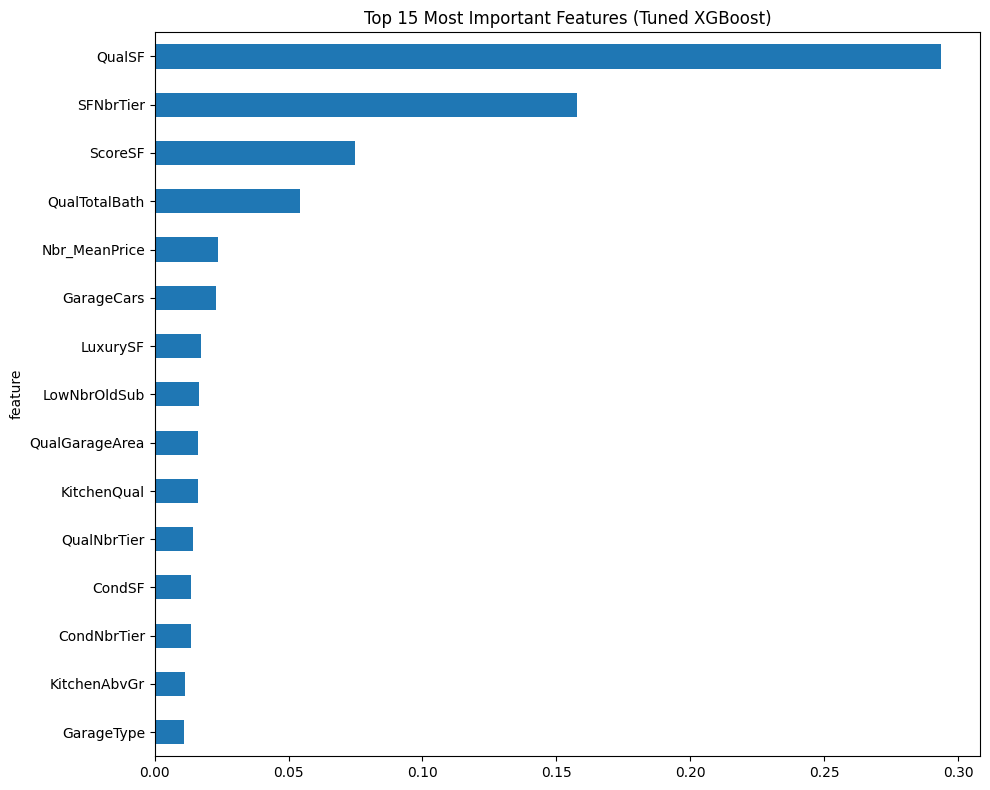

In [16]:
importance_df = pd.DataFrame()
for model, nbr_mean, nbr_std, nbr_cov in xgb_models:
    imp = pd.DataFrame({
        "feature":    model.feature_names_in_,
        "importance": model.feature_importances_
    })
    importance_df = pd.concat([importance_df, imp])

avg_importance = (importance_df
                  .groupby("feature")["importance"]
                  .mean()
                  .sort_values(ascending=False)
                  .reset_index())

fig, ax = plt.subplots(figsize=(10, 8))
avg_importance.head(15).plot.barh(x="feature", y="importance", ax=ax, legend=False)
ax.set_title("Top 15 Most Important Features (Tuned XGBoost)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 7. LGBM Model

We will use another gradient boosting model to ensemble with our XGBoost model to hopefully fix some of the errors of our first model.

## 7.1. Hyperparameter Tuning

In [17]:
import lightgbm as lgb

def lgb_objective(trial):
    params = {
        # ── tree structure ─────────────────────────────────────────────────────
        "num_leaves":       trial.suggest_int(  "num_leaves",       20,   150), 
        "max_depth":        trial.suggest_int(  "max_depth",        3,    8),
        "min_child_samples":trial.suggest_int(  "min_child_samples",10,   100),       

        # ── sampling ───────────────────────────────────────────────────────────
        "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.1,  log=True),
        "subsample":        trial.suggest_float("subsample",        0.5,  0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5,  0.9),
        "subsample_freq":   1,                                 

        # ── regularisation ─────────────────────────────────────────────────────
        "reg_alpha":        trial.suggest_float("reg_alpha",        0.01, 2.0,  log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda",       0.01, 2.0,  log=True),
        "min_split_gain":   trial.suggest_float("min_split_gain",   0.0,  1.0),    

        # ── fixed params ───────────────────────────────────────────────────────
        "objective":        "regression",
        "metric":           "rmse",
        "verbose":          -1,
        "n_jobs":           -1,
    }

    from sklearn.model_selection import StratifiedKFold
    price_buckets = pd.qcut(y_train, q=10, labels=False)
    skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof           = np.zeros(len(X_train))

    for train_idx, val_idx in skf.split(X_train, price_buckets):
        X_tr  = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # ── neighbourhood encoding (same as XGBoost) ──────────────────────────
        nbr_mean = y_tr.groupby(X_tr["Neighborhood"].astype(str)).mean()
        nbr_std  = y_tr.groupby(X_tr["Neighborhood"].astype(str)).std()
        nbr_cov  = nbr_std / nbr_mean

        X_tr["Nbr_MeanPrice"]       = X_tr["Neighborhood"].astype(str).map(nbr_mean)
        X_val["Nbr_MeanPrice"]      = X_val["Neighborhood"].astype(str).map(nbr_mean).fillna(y_tr.mean())
        X_tr["Nbr_StdPrice"]        = X_tr["Neighborhood"].astype(str).map(nbr_std)
        X_val["Nbr_StdPrice"]       = X_val["Neighborhood"].astype(str).map(nbr_std).fillna(y_tr.std())
        X_tr["Nbr_CoV"]             = X_tr["Neighborhood"].astype(str).map(nbr_cov)
        X_val["Nbr_CoV"]            = X_val["Neighborhood"].astype(str).map(nbr_cov).fillna(nbr_cov.mean())
        X_tr["QualStdInteraction"]  = X_tr["OverallQual"] * X_tr["Nbr_StdPrice"]
        X_val["QualStdInteraction"] = X_val["OverallQual"] * X_val["Nbr_StdPrice"]
        X_tr["SFStdInteraction"]    = X_tr["TotalSF"]     * X_tr["Nbr_StdPrice"]
        X_val["SFStdInteraction"]   = X_val["TotalSF"]    * X_val["Nbr_StdPrice"]

        # ── convert category cols to int for LightGBM ─────────────────────────
        X_tr_lgb  = X_tr.copy()
        X_val_lgb = X_val.copy()
        cat_cols  = X_tr_lgb.select_dtypes(include=["category"]).columns
        for col in cat_cols:
            X_tr_lgb[col]  = X_tr_lgb[col].cat.codes
            X_val_lgb[col] = X_val_lgb[col].cat.codes

        model = lgb.LGBMRegressor(
            **params,
            n_estimators=5000,
            random_state=42,
        )
        model.fit(
            X_tr_lgb, y_tr,
            eval_set=[(X_val_lgb, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )
        oof[val_idx] = model.predict(X_val_lgb)

    return root_mean_squared_error(y_train, oof)


lgb_study = optuna.create_study(direction="minimize")
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest OOF RMSE:  {lgb_study.best_value:.5f}")
print(f"Best params:    {lgb_study.best_params}")

[I 2026-03-22 10:13:48,402] A new study created in memory with name: no-name-8b760d33-66f0-4c8d-8ec0-1d19df89bb92
Best trial: 0. Best value: 0.150674:   2%|▏         | 1/50 [00:00<00:27,  1.79it/s]

[I 2026-03-22 10:13:48,962] Trial 0 finished with value: 0.15067445362096304 and parameters: {'num_leaves': 147, 'max_depth': 7, 'min_child_samples': 89, 'learning_rate': 0.012024870755159284, 'subsample': 0.8832389493047746, 'colsample_bytree': 0.8803113090637149, 'reg_alpha': 0.929805240222746, 'reg_lambda': 0.11597569093834978, 'min_split_gain': 0.9682129481033035}. Best is trial 0 with value: 0.15067445362096304.


Best trial: 1. Best value: 0.128753:   4%|▍         | 2/50 [00:00<00:18,  2.54it/s]

[I 2026-03-22 10:13:49,240] Trial 1 finished with value: 0.128752517388327 and parameters: {'num_leaves': 62, 'max_depth': 4, 'min_child_samples': 17, 'learning_rate': 0.08443219663776541, 'subsample': 0.6776370023164874, 'colsample_bytree': 0.6507818365770954, 'reg_alpha': 0.028151713484915235, 'reg_lambda': 0.07496727538989123, 'min_split_gain': 0.3604861314206689}. Best is trial 1 with value: 0.128752517388327.


Best trial: 1. Best value: 0.128753:   6%|▌         | 3/50 [00:01<00:20,  2.31it/s]

...

[I 2026-03-22 10:14:32,696] Trial 47 finished with value: 0.12451190732840209 and parameters: {'num_leaves': 137, 'max_depth': 7, 'min_child_samples': 61, 'learning_rate': 0.01739690720471454, 'subsample': 0.7431988414036301, 'colsample_bytree': 0.7774500135694453, 'reg_alpha': 0.1534271148273183, 'reg_lambda': 0.7093625885067, 'min_split_gain': 0.06357502855436256}. Best is trial 44 with value: 0.11719014582663428.


Best trial: 44. Best value: 0.11719:  98%|█████████▊| 49/50 [00:44<00:00,  1.06it/s]

[I 2026-03-22 10:14:33,144] Trial 48 finished with value: 0.13227009090451225 and parameters: {'num_leaves': 148, 'max_depth': 4, 'min_child_samples': 33, 'learning_rate': 0.026945811281457746, 'subsample': 0.679516004917501, 'colsample_bytree': 0.7273494880197123, 'reg_alpha': 0.3061983860637146, 'reg_lambda': 0.010795351791718021, 'min_split_gain': 0.4258062371876602}. Best is trial 44 with value: 0.11719014582663428.


Best trial: 44. Best value: 0.11719: 100%|██████████| 50/50 [00:45<00:00,  1.10it/s]

[I 2026-03-22 10:14:33,943] Trial 49 finished with value: 0.12588986159047752 and parameters: {'num_leaves': 150, 'max_depth': 8, 'min_child_samples': 52, 'learning_rate': 0.02001010486624684, 'subsample': 0.7789709808960429, 'colsample_bytree': 0.6363892899018222, 'reg_alpha': 0.21897322663253838, 'reg_lambda': 1.5854400019601838, 'min_split_gain': 0.16726177853355095}. Best is trial 44 with value: 0.11719014582663428.

Best OOF RMSE:  0.11719
Best params:    {'num_leaves': 144, 'max_depth': 7, 'min_child_samples': 56, 'learning_rate': 0.018420014228386867, 'subsample': 0.7210883355312467, 'colsample_bytree': 0.8388099809938039, 'reg_alpha': 0.30884340718385145, 'reg_lambda': 1.6195824071847391, 'min_split_gain': 0.0038125270591944076}


## 7.2. Validating LGBM

In [18]:
from model_validation import cross_validate_lgb_stratified

lgb_best_params = {
    **lgb_study.best_params,
    "objective":      "regression",
    "metric":         "rmse",
    "n_jobs":         -1,
    "subsample_freq": 1,
}

lgb_models, lgb_oof, lgb_fold_scores = cross_validate_lgb_stratified(
    X_train, y_train,
    lgb_best_params,
    n_splits=5,
    n_estimators=5000,
    early_stopping_rounds=50
)


--- Fold 1 / 5 ---
[100]	valid_0's rmse: 0.16024
[200]	valid_0's rmse: 0.135107
[300]	valid_0's rmse: 0.129668
[400]	valid_0's rmse: 0.127566
[500]	valid_0's rmse: 0.126707
[600]	valid_0's rmse: 0.125985
[700]	valid_0's rmse: 0.125644
Fold 1 RMSE: 0.12552

--- Fold 2 / 5 ---
[100]	valid_0's rmse: 0.167316
[200]	valid_0's rmse: 0.132986
[300]	valid_0's rmse: 0.124661
[400]	valid_0's rmse: 0.121607
[500]	valid_0's rmse: 0.119955
[600]	valid_0's rmse: 0.118486
[700]	valid_0's rmse: 0.117403
[800]	valid_0's rmse: 0.117045
[900]	valid_0's rmse: 0.11668
[1000]	valid_0's rmse: 0.116342
[1100]	valid_0's rmse: 0.115977
Fold 2 RMSE: 0.11588

--- Fold 3 / 5 ---
[100]	valid_0's rmse: 0.166512
[200]	valid_0's rmse: 0.141777
[300]	valid_0's rmse: 0.134681
[400]	valid_0's rmse: 0.130823
[500]	valid_0's rmse: 0.128675
[600]	valid_0's rmse: 0.127217
[700]	valid_0's rmse: 0.125904
[800]	valid_0's rmse: 0.125042
[900]	valid_0's rmse: 0.124522
[1000]	valid_0's rmse: 0.12399
[1100]	valid_0's rmse: 0.12362

## 7.3. LGB vs XGBoost

In [19]:
# ── compare against XGBoost ───────────────────────────────────────────────────
print("\n=== Model Comparison ===")
print(f"XGBoost OOF RMSE:  {root_mean_squared_error(y_train, xgb_oof):.5f}")
print(f"LightGBM OOF RMSE: {root_mean_squared_error(y_train, lgb_oof):.5f}")

corr = np.corrcoef(xgb_oof, lgb_oof)[0, 1]
print(f"\nOOF prediction correlation: {corr:.4f}")
print("(lower = more diverse = more benefit from blending)")

# ── check where models disagree most ─────────────────────────────────────────
disagreement = pd.DataFrame({
    "actual":     np.expm1(y_train),
    "xgb":        np.expm1(xgb_oof),
    "lgb":        np.expm1(lgb_oof),
    "difference": np.abs(np.expm1(xgb_oof) - np.expm1(lgb_oof)),
    "xgb_err":    np.abs(np.expm1(xgb_oof) - np.expm1(y_train)),
    "lgb_err":    np.abs(np.expm1(lgb_oof) - np.expm1(y_train)),
}, index=X_train.index)

print("\nHouses where models disagree most:")
print(disagreement.nlargest(10, "difference")[
    ["actual", "xgb", "lgb", "difference", "xgb_err", "lgb_err"]
].to_string())


=== Model Comparison ===
XGBoost OOF RMSE:  0.11426
LightGBM OOF RMSE: 0.11752

OOF prediction correlation: 0.9944
(lower = more diverse = more benefit from blending)

Houses where models disagree most:
        actual            xgb            lgb    difference       xgb_err        lgb_err
Id                                                                                     
1244  465000.0  512490.015843  449900.974555  62589.041288  47490.015843   15099.025445
655   350000.0  415795.438084  359647.636851  56147.801232  65795.438084    9647.636851
1374  466500.0  440488.421086  389752.082313  50736.338773  26011.578914   76747.917687
441   555000.0  467786.737821  423497.749415  44288.988406  87213.262179  131502.250585
474   440000.0  360935.144625  403840.917163  42905.772538  79064.855375   36159.082837
225   386250.0  403623.134856  360754.711066  42868.423790  17373.134856   25495.288934
350   437154.0  467504.876732  425256.623589  42248.253142  30350.876732   11897.376411
179 

## 7.4. Ensembling Models

In [20]:
from scipy.optimize import minimize_scalar

def blend_score(w):
    blended = w * xgb_oof + (1 - w) * lgb_oof
    return root_mean_squared_error(y_train, blended)

result     = minimize_scalar(blend_score, bounds=(0, 1), method="bounded")
best_w_xgb = result.x
best_w_lgb = 1 - best_w_xgb

print(f"\n=== Optimal Blend ===")
print(f"XGBoost weight:   {best_w_xgb:.3f}")
print(f"LightGBM weight:  {best_w_lgb:.3f}")
print(f"XGBoost OOF RMSE: {root_mean_squared_error(y_train, xgb_oof):.5f}")
print(f"LightGBM OOF RMSE:{root_mean_squared_error(y_train, lgb_oof):.5f}")
print(f"Blended OOF RMSE: {result.fun:.5f}")
print(f"Improvement over XGBoost: {root_mean_squared_error(y_train, xgb_oof) - result.fun:.5f}")


=== Optimal Blend ===
XGBoost weight:   0.746
LightGBM weight:  0.254
XGBoost OOF RMSE: 0.11426
LightGBM OOF RMSE:0.11752
Blended OOF RMSE: 0.11382
Improvement over XGBoost: 0.00043


# 8. Linear Models

We will add a few linear models to the mix to have some diversity rather than purely gradient boosting models.

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.svm import SVR
from scipy.special import boxcox1p
from scipy.stats import skew, boxcox_normmax



def prepare_linear_features(X_train, X_test):
    n_train  = len(X_train)
    combined = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

    # ── one-hot encode all category columns ───────────────────────────────────
    cat_cols = combined.select_dtypes(include=["category"]).columns
    combined = pd.get_dummies(combined, columns=cat_cols)

    # ── fill nulls before skew calculation ────────────────────────────────────
    combined = combined.fillna(0)

    # ── box-cox transform skewed numeric columns ──────────────────────────────
    num_cols  = combined.select_dtypes(include=[np.number]).columns
    skewness  = combined[num_cols].apply(lambda x: skew(x))
    high_skew = skewness[skewness > 0.5].index

    for col in high_skew:
        col_data = combined[col].clip(lower=0) + 1  # shift to strictly positive

        # skip if column has any non-finite or non-positive values
        if not (np.isfinite(col_data).all() and (col_data > 0).all()):
            continue

        # skip near-constant columns — boxcox fails on zero-variance data
        if col_data.std() < 1e-10:
            continue

        try:
            lam = boxcox_normmax(col_data)
            combined[col] = boxcox1p(combined[col].clip(lower=0), lam)
        except Exception:
            # if boxcox still fails for any reason, just apply log1p instead
            combined[col] = np.log1p(combined[col].clip(lower=0))

    # ── drop near-constant columns (>99.9% same value) ────────────────────────
    overfit_cols = []
    for col in combined.columns:
        counts = combined.iloc[:n_train][col].value_counts()
        if len(counts) > 0 and counts.iloc[0] / n_train > 0.999:
            overfit_cols.append(col)
    combined = combined.drop(columns=overfit_cols)

    X_tr = combined.iloc[:n_train].reset_index(drop=True)
    X_te = combined.iloc[n_train:].reset_index(drop=True)

    print(f"Linear features shape:    {X_tr.shape}")
    print(f"Dropped near-constant:    {len(overfit_cols)} columns")
    print(f"Remaining nulls in train: {X_tr.isnull().sum().sum()}")

    return X_tr, X_te


def cross_validate_linear_stratified(X, y, model, model_name,
                                      n_splits=5, scale=True):
    """
    CV for linear models with optional scaling.
    Returns OOF predictions and fold scores.
    """
    from sklearn.model_selection import StratifiedKFold

    price_buckets   = pd.qcut(y, q=10, labels=False)
    skf             = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_predictions = np.zeros(len(X))
    fold_scores     = []
    fitted_models   = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, price_buckets)):
        X_tr  = X.iloc[train_idx].values
        X_val = X.iloc[val_idx].values
        y_tr  = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        if scale:
            scaler = RobustScaler()
            X_tr  = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)
        else:
            scaler = None

        model.fit(X_tr, y_tr)
        oof_predictions[val_idx] = model.predict(X_val)

        fold_rmse = root_mean_squared_error(y_val, oof_predictions[val_idx])
        fold_scores.append(fold_rmse)
        fitted_models.append((model, scaler))

        print(f"  Fold {fold+1} RMSE: {fold_rmse:.5f}")

    oof_rmse = root_mean_squared_error(y, oof_predictions)
    print(f"  {model_name} OOF RMSE: {oof_rmse:.5f} | Std: {np.std(fold_scores):.5f}")
    return fitted_models, oof_predictions, fold_scores


def predict_linear_ensemble(fitted_models, X_test, scale=True):
    """Average predictions across all fold models."""
    preds = []
    for model, scaler in fitted_models:
        X_t = X_test.values
        if scale and scaler is not None:
            X_t = scaler.transform(X_t)
        preds.append(model.predict(X_t))
    return np.column_stack(preds).mean(axis=1)

from sklearn.model_selection import KFold
import copy

kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=[14.5, 14.6, 14.7, 14.8, 14.9, 15.0, 15.1, 15.2, 15.3, 15.4, 15.5],
    cv=kfolds
)
lasso = LassoCV(
    max_iter=int(1e7),
    alphas=[5e-05, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008],
    random_state=42,
    cv=kfolds
)
elasticnet = ElasticNetCV(
    max_iter=int(1e7),
    alphas=[0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007],
    l1_ratio=[0.8, 0.85, 0.9, 0.95, 0.99, 1],
    cv=kfolds
)
svr = SVR(C=20, epsilon=0.008, gamma=0.0003)

# ── Step 1: prepare linear features from X_train/X_test (not X_full) ─────────
X_train_lin, X_test_lin = prepare_linear_features(X_train, X_test)

# ── Step 2: train linear models on X_train for OOF comparison ────────────────
print("Training Ridge...")
ridge_models, ridge_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, ridge, "Ridge"
)

print("\nTraining Lasso...")
lasso_models, lasso_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, lasso, "Lasso"
)

print("\nTraining ElasticNet...")
en_models, en_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, elasticnet, "ElasticNet"
)

print("\nTraining SVR...")
svr_models, svr_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, svr, "SVR"
)

Linear features shape:    (1163, 314)
Dropped near-constant:    11 columns
Remaining nulls in train: 0
Training Ridge...
  Fold 1 RMSE: 0.12027
  Fold 2 RMSE: 0.10917
  Fold 3 RMSE: 0.10691
  Fold 4 RMSE: 0.09063
  Fold 5 RMSE: 0.10201
  Ridge OOF RMSE: 0.10625 | Std: 0.00966

Training Lasso...
  Fold 1 RMSE: 0.12126
  Fold 2 RMSE: 0.10920
  Fold 3 RMSE: 0.10761
  Fold 4 RMSE: 0.09091
  Fold 5 RMSE: 0.10125
  Lasso OOF RMSE: 0.10653 | Std: 0.00996

Training ElasticNet...
  Fold 1 RMSE: 0.12126
  Fold 2 RMSE: 0.10957
  Fold 3 RMSE: 0.10727
  Fold 4 RMSE: 0.09032
  Fold 5 RMSE: 0.10167
  ElasticNet OOF RMSE: 0.10652 | Std: 0.01012

Training SVR...
  Fold 1 RMSE: 0.13450
  Fold 2 RMSE: 0.12025
  Fold 3 RMSE: 0.13557
  Fold 4 RMSE: 0.10807
  Fold 5 RMSE: 0.14078
  SVR OOF RMSE: 0.12840 | Std: 0.01200


# 9. Make Submission

With our model made, we will create our final predictions for our submission.

## 9.1. Retraining on Full Dataset

Since we are making our final model, we will retrain everything on the full dataset.

In [23]:
# ── combine train and test splits into full training data ─────────────────────
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

X_full = X_full.drop(columns=[c for c in drop_cols if c in X_full.columns])

# ── retrain both models on full data ──────────────────────────────────────────
price_buckets = pd.qcut(y_full, q=10, labels=False)

xgb_models, xgb_oof, _ = cross_validate_xgb_stratified(
    X_full, y_full,
    xgb_params,
    n_splits=5,
    n_estimators=5000,
    early_stopping_rounds=50
)

print("\nRetraining LightGBM on full data...")
lgb_models, lgb_oof, _ = cross_validate_lgb_stratified(
    X_full, y_full,
    lgb_best_params,
    n_splits=5,
    n_estimators=5000,
    early_stopping_rounds=50
)

print(f"\nFull data XGBoost OOF RMSE:  {root_mean_squared_error(y_full, xgb_oof):.5f}")
print(f"Full data LightGBM OOF RMSE: {root_mean_squared_error(y_full, lgb_oof):.5f}")


--- Fold 1 / 5 ---
[0]	validation_0-rmse:0.37808
[100]	validation_0-rmse:0.11866
[200]	validation_0-rmse:0.10956
[300]	validation_0-rmse:0.10837
[400]	validation_0-rmse:0.10736
[464]	validation_0-rmse:0.10734
Fold 1 RMSE: 0.10718 | Best iteration: 414

--- Fold 2 / 5 ---
[0]	validation_0-rmse:0.38964
[100]	validation_0-rmse:0.11995
[200]	validation_0-rmse:0.10980
[300]	validation_0-rmse:0.10784
[400]	validation_0-rmse:0.10718
[500]	validation_0-rmse:0.10677
[600]	validation_0-rmse:0.10668
[604]	validation_0-rmse:0.10669
Fold 2 RMSE: 0.10653 | Best iteration: 554

--- Fold 3 / 5 ---
[0]	validation_0-rmse:0.38479
[100]	validation_0-rmse:0.12306
[200]	validation_0-rmse:0.11562
[300]	validation_0-rmse:0.11446
[400]	validation_0-rmse:0.11435
[419]	validation_0-rmse:0.11441
Fold 3 RMSE: 0.11416 | Best iteration: 369

--- Fold 4 / 5 ---
[0]	validation_0-rmse:0.37723
[100]	validation_0-rmse:0.13014
[200]	validation_0-rmse:0.12336
[300]	validation_0-rmse:0.12125
[400]	validation_0-rmse:0.12076

## 9.2. Recalculate Blend Scores

In [25]:
# ── re-run XGBoost and LightGBM on X_train to get 1163-row OOFs ──────────────
print("Running XGBoost on X_train...")
xgb_models_train, xgb_oof_train, _ = cross_validate_xgb_stratified(
    X_train, y_train, xgb_params, n_splits=5, n_estimators=5000
)

print("\nRunning LightGBM on X_train...")
lgb_models_train, lgb_oof_train, _ = cross_validate_lgb_stratified(
    X_train, y_train, lgb_best_params, n_splits=5, n_estimators=5000
)

# ── prepare linear features from X_train/X_test ───────────────────────────────
X_train_lin, X_test_lin = prepare_linear_features(X_train, X_test)

# ── train linear models on X_train ────────────────────────────────────────────
print("\nTraining Ridge...")
ridge_models, ridge_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, ridge, "Ridge"
)
print("\nTraining Lasso...")
lasso_models, lasso_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, lasso, "Lasso"
)
print("\nTraining ElasticNet...")
en_models, en_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, elasticnet, "ElasticNet"
)
print("\nTraining SVR...")
svr_models, svr_oof, _ = cross_validate_linear_stratified(
    X_train_lin, y_train, svr, "SVR"
)

# ── compare OOF scores — all against y_train (1163 rows) ─────────────────────
all_oofs = {
    "xgb":        xgb_oof_train,   # ← use _train suffix versions
    "lgb":        lgb_oof_train,   # ← use _train suffix versions
    "ridge":      ridge_oof,
    "lasso":      lasso_oof,
    "elasticnet": en_oof,
    "svr":        svr_oof,
}

print("\n=== Individual OOF Scores (vs y_train) ===")
for name, oof in all_oofs.items():
    print(f"{name:15s}: {root_mean_squared_error(y_train, oof):.5f}  (len={len(oof)})")

# ── find optimal blend weights ────────────────────────────────────────────────
from scipy.optimize import minimize

oof_matrix = np.column_stack(list(all_oofs.values()))
n_models   = oof_matrix.shape[1]

def blend_score_multi(weights):
    weights = np.array(weights)
    weights = weights / weights.sum()
    blended = oof_matrix @ weights
    return root_mean_squared_error(y_train, blended)

result = minimize(
    blend_score_multi,
    x0=[1/n_models] * n_models,
    method="SLSQP",
    bounds=[(0, 1)] * n_models,
    constraints={"type": "eq", "fun": lambda w: sum(w) - 1}
)

best_weights = result.x / result.x.sum()

print("\n=== Optimal Blend Weights ===")
for name, w in zip(all_oofs.keys(), best_weights):
    print(f"{name:15s}: {w:.3f}")
print(f"\nBlended OOF RMSE: {result.fun:.5f}")
print(f"Best individual:  {min(root_mean_squared_error(y_train, oof) for oof in all_oofs.values()):.5f}")

X_final  = pd.read_csv("test.csv")
test_ids = X_final["Id"]
X_final  = X_final.drop(columns=["Id"])

X_final = engineer_features(X_final)
X_final = fill_missing(X_final)

# ── drop same columns as training ─────────────────────────────────────────────
X_final = X_final.drop(columns=[c for c in drop_cols if c in X_final.columns])

# ── align categories to X_full ────────────────────────────────────────────────
cat_cols = X_full.select_dtypes(include=["category"]).columns
for col in cat_cols:
    if col in X_final.columns:
        full_cats     = X_full[col].cat.categories
        X_final[col]  = X_final[col].astype("category").cat.set_categories(full_cats)

# catch any remaining str columns
remaining_str = X_final.select_dtypes(include=["object", "str"]).columns
for col in remaining_str:
    if col in X_full.columns:
        full_cats    = X_full[col].cat.categories
        X_final[col] = X_final[col].astype("category").cat.set_categories(full_cats)
    else:
        X_final[col] = X_final[col].astype("category")

# verify no str columns remain
still_str = X_final.select_dtypes(include=["object", "str"]).columns.tolist()
if still_str:
    print(f"WARNING: still str dtype: {still_str}")
else:
    print("All columns correctly typed")

# ── retrain everything on X_full for final submission ─────────────────────────
X_full_lin, X_final_lin = prepare_linear_features(X_full, X_final)

print("\nRetraining on full data...")
xgb_models, xgb_oof, _  = cross_validate_xgb_stratified(X_full, y_full, xgb_params,      n_splits=5, n_estimators=5000)
lgb_models, lgb_oof, _  = cross_validate_lgb_stratified(X_full, y_full, lgb_best_params,  n_splits=5, n_estimators=5000)
ridge_models_full, _, _ = cross_validate_linear_stratified(X_full_lin, y_full, ridge,      "Ridge")
lasso_models_full, _, _ = cross_validate_linear_stratified(X_full_lin, y_full, lasso,      "Lasso")
en_models_full,    _, _ = cross_validate_linear_stratified(X_full_lin, y_full, elasticnet, "ElasticNet")
svr_models_full,   _, _ = cross_validate_linear_stratified(X_full_lin, y_full, svr,        "SVR")

Running XGBoost on X_train...

--- Fold 1 / 5 ---
[0]	validation_0-rmse:0.37801
[100]	validation_0-rmse:0.13286
[200]	validation_0-rmse:0.12305
[300]	validation_0-rmse:0.12082
[400]	validation_0-rmse:0.11980
[500]	validation_0-rmse:0.11942
[551]	validation_0-rmse:0.11962
Fold 1 RMSE: 0.11941 | Best iteration: 501

--- Fold 2 / 5 ---
[0]	validation_0-rmse:0.38892
[100]	validation_0-rmse:0.13011
[200]	validation_0-rmse:0.11540
[300]	validation_0-rmse:0.11217
[400]	validation_0-rmse:0.11171
[500]	validation_0-rmse:0.11135
[583]	validation_0-rmse:0.11156
Fold 2 RMSE: 0.11125 | Best iteration: 533

--- Fold 3 / 5 ---
[0]	validation_0-rmse:0.38438
[100]	validation_0-rmse:0.13255
[200]	validation_0-rmse:0.12432
[300]	validation_0-rmse:0.12215
[400]	validation_0-rmse:0.12129
[500]	validation_0-rmse:0.12109
[513]	validation_0-rmse:0.12110
Fold 3 RMSE: 0.12096 | Best iteration: 463

--- Fold 4 / 5 ---
[0]	validation_0-rmse:0.35716
[100]	validation_0-rmse:0.10864
[200]	validation_0-rmse:0.10394
[

## 9.3. Making Final Submission Predictions

In [29]:
from model_validation import predict_ensemble, predict_lgb_ensemble

# ── generate test predictions ─────────────────────────────────────────────────
xgb_test_preds = predict_ensemble(xgb_models, X_final)
lgb_test_preds = predict_lgb_ensemble(lgb_models, X_final)

all_test_preds = [
    xgb_test_preds,
    lgb_test_preds,
    predict_linear_ensemble(ridge_models_full, X_final_lin),
    predict_linear_ensemble(lasso_models_full, X_final_lin),
    predict_linear_ensemble(en_models_full,    X_final_lin),
    predict_linear_ensemble(svr_models_full,   X_final_lin),
]

test_preds_log = sum(w * preds for w, preds in zip(best_weights, all_test_preds))
test_preds     = np.expm1(test_preds_log)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_preds})
submission.to_csv("submission.csv", index=False)
print(f"\nsubmission.csv saved")
print(submission["SalePrice"].describe())


submission.csv saved
count      1459.000000
mean     179524.096002
std       78650.649832
min       51683.572544
25%      127622.678695
50%      157671.291139
75%      210161.825975
max      784501.414271
Name: SalePrice, dtype: float64
